# 데이터 검증 

1. 데이터 규격 및 차원 검증
2. 시간표 연동 및 행동별 정렬 
3. 파동 시각화 
4. 정답지 3D 시각화 

* 데이터 검증이니 일부 데이터 셋만 이용을 함 
* NN을 돌릴수 있게 가공하는 것은 나중에 함 

1단계 — 데이터 로딩 + 규격 검증

이 단계 목표:

CSI 전체 로딩
GT 로딩
shape 확인

In [1]:
import os
import numpy as np
from scipy.io import loadmat

# ====================================
# 경로 설정
# ====================================

BASE_PATH = "E01/S01/A02"

CSI_PATH = os.path.join(BASE_PATH, "wifi-csi")
GT_PATH = os.path.join(BASE_PATH, "ground_truth.npy")

# ====================================
# CSI 로딩
# ====================================

csi_files = sorted(os.listdir(CSI_PATH))

csi_list = []

for file in csi_files:

    path = os.path.join(CSI_PATH, file)

    data = loadmat(path)

    amp = data["CSIamp"]
    phase = data["CSIphase"]

    csi_complex = amp * np.exp(
        1j * phase
    )

    csi_list.append(csi_complex)

csi_tensor = np.array(csi_list)

# ====================================
# GT 로딩
# ====================================

gt = np.load(GT_PATH)

# ====================================
# Shape 확인
# ====================================

print("CSI Shape :", csi_tensor.shape)
print("GT Shape  :", gt.shape)

# ====================================
# Frame 정렬
# ====================================

min_frames = min(
    csi_tensor.shape[0],
    gt.shape[0]
)

csi_tensor = csi_tensor[:min_frames]
gt = gt[:min_frames]

print("\nAfter Align")
print("CSI Shape :", csi_tensor.shape)
print("GT Shape  :", gt.shape)

CSI Shape : (297, 3, 114, 10)
GT Shape  : (297, 17, 3)

After Align
CSI Shape : (297, 3, 114, 10)
GT Shape  : (297, 17, 3)


C:\Users\yujaerim\AppData\Local\Temp\ipykernel_33952\3176493270.py:31: RuntimeWarning: invalid value encountered in multiply
  csi_complex = amp * np.exp(


2단계 — CSI / GT 시각화

이 단계 목표:

CSI 패턴 보기
3D Pose 확인

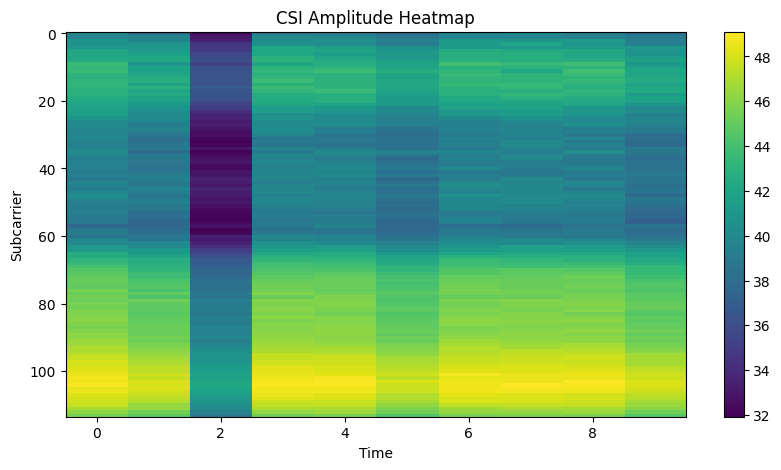

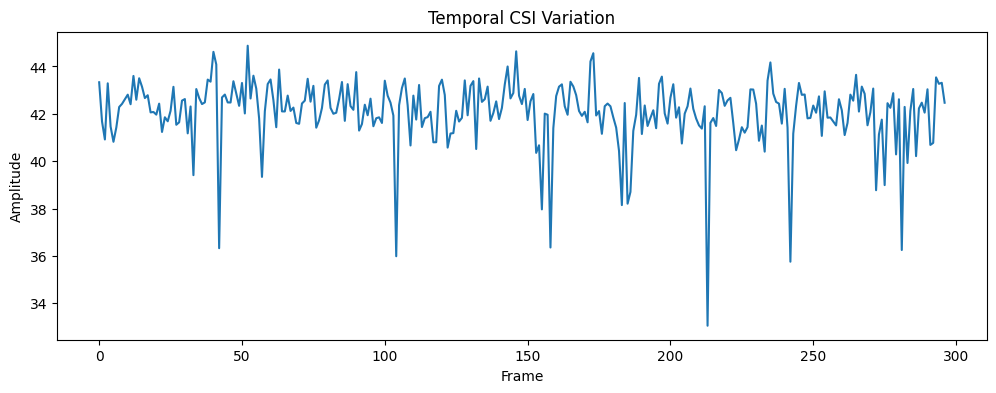

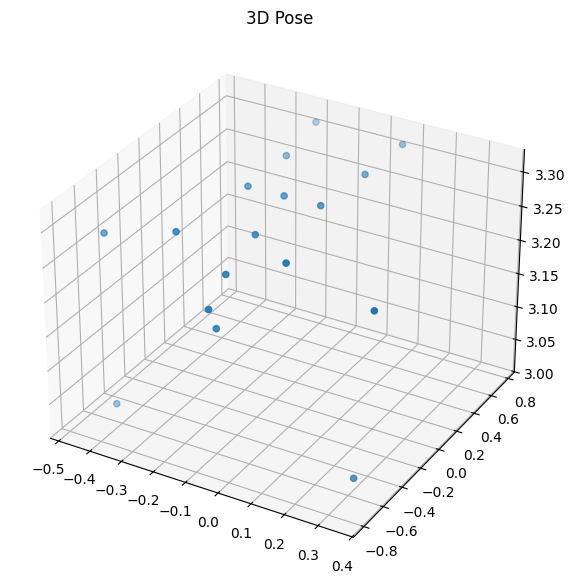

In [2]:
import matplotlib.pyplot as plt

# ====================================
# CSI Heatmap
# ====================================

amp_vis = np.abs(
    csi_tensor[0, 0]
)

plt.figure(figsize=(10,5))

plt.imshow(
    amp_vis,
    aspect='auto'
)

plt.colorbar()

plt.title("CSI Amplitude Heatmap")

plt.xlabel("Time")
plt.ylabel("Subcarrier")

plt.show()

# ====================================
# Temporal 변화
# ====================================

signal = np.abs(
    csi_tensor[:,0,10,0]
)

plt.figure(figsize=(12,4))

plt.plot(signal)

plt.title(
    "Temporal CSI Variation"
)

plt.xlabel("Frame")
plt.ylabel("Amplitude")

plt.show()

# ====================================
# GT 3D 시각화
# ====================================

frame_idx = 0

pose = gt[frame_idx]

fig = plt.figure(figsize=(7,7))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(
    pose[:,0],
    pose[:,1],
    pose[:,2]
)

ax.set_title("3D Pose")

plt.show()

2번째 그림을 보면 가끔 딥하게 곡선이 생기는데 이는 multipath 경로 위상 충돌 , fading 이 2개의 원인때문에 생기는 것이다. 

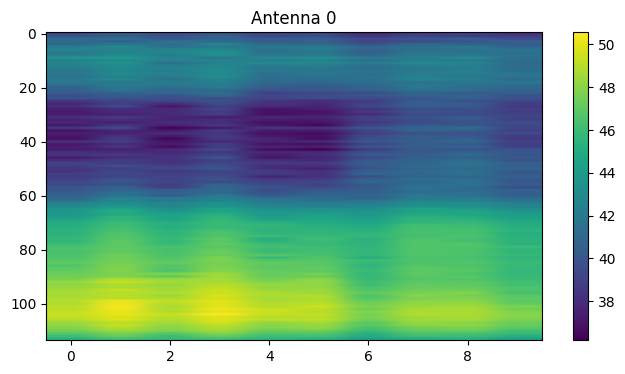

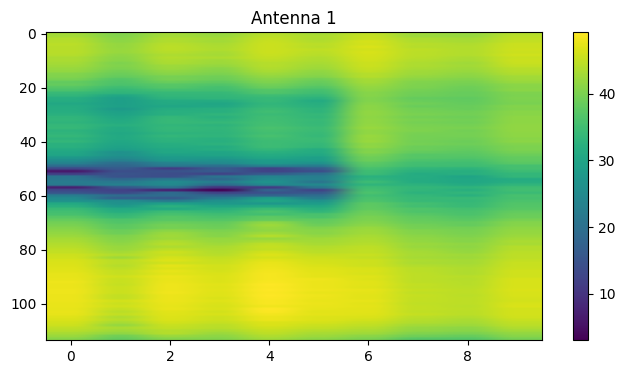

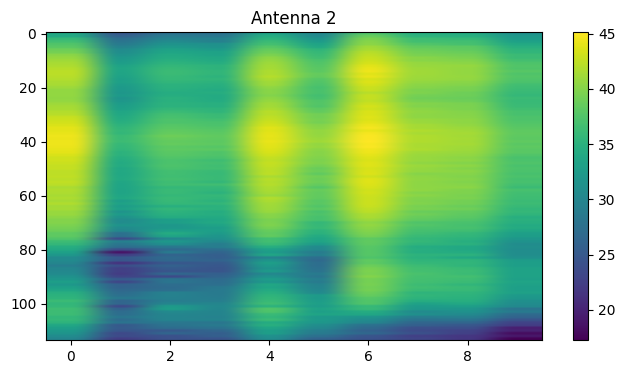

In [3]:
import matplotlib.pyplot as plt

for i in range(3):

    plt.figure(figsize=(8,4))

    plt.imshow(
        data["CSIamp"][i],
        aspect='auto'
    )

    plt.title(f"Antenna {i}")

    plt.colorbar()

    plt.show()

#### 3. 안테나별 패턴

1. Antenna 0
```
상대적으로: 안정적 gradient 중심
```
2. Antenna 1
```
특정 구간에서 : 강한 attenuation 보임.
특히 50~60 subcarrier 근처.
```
* 즉:spatial diversity , antenna 위치 차이가 존재한다는 뜻.

3. Antenna 2
```
패턴이 가장 dynamic함.
즉: 안테나마다 서로 다른 multipath 관측하고 있다는 뜻.
```

In [6]:
import os
import numpy as np
from scipy.io import loadmat

env_dirs = [
    "../E01",
    "../E02",
    "../E03"
]

target_actions = [
    "A01",
    "A12",
    "A08",
    "A27"
]

all_amp = []

for env in env_dirs:

    for subject in os.listdir(env):

        subject_path = os.path.join(env, subject)

        if not os.path.isdir(subject_path):
            continue

        for action in target_actions:

            action_path = os.path.join(
                subject_path,
                action,
                "wifi-csi"
            )

            if not os.path.exists(action_path):
                continue

            mat_files = sorted(
                f for f in os.listdir(action_path)
                if f.endswith(".mat")
            )

            for file in mat_files:

                data = loadmat(
                    os.path.join(action_path, file)
                )

                amp = data["CSIamp"]

                all_amp.append(amp)

all_amp = np.array(all_amp)

print("Shape:", all_amp.shape)

Shape: (35640, 3, 114, 10)


### 증강을 위한 통계추출
* Flatten 하기 전에 증강해야 함.

In [8]:
print(all_amp.shape)
print(all_amp.dtype)

print(type(all_amp[0]))
print(all_amp[0].shape)

(35640, 3, 114, 10)
float64
<class 'numpy.ndarray'>
(3, 114, 10)


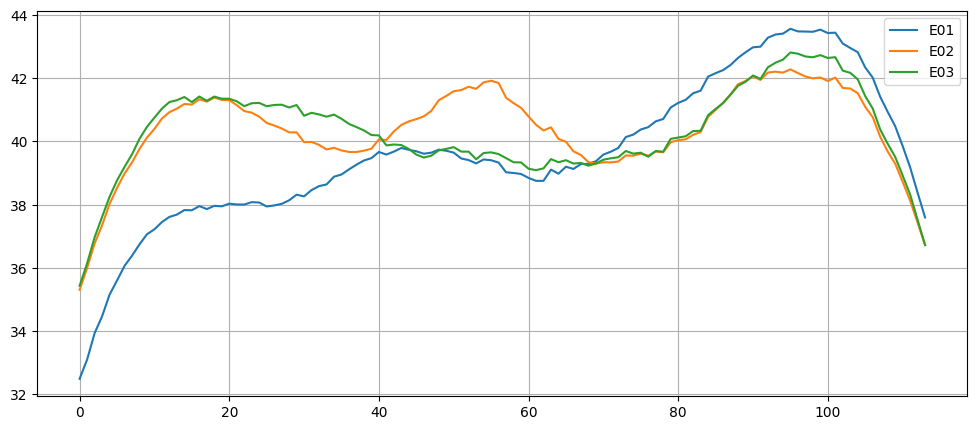

In [13]:
def env_profile(env):

    amps = []

    for subject in os.listdir(env):

        subject_path = os.path.join(env, subject)

        if not os.path.isdir(subject_path):
            continue

        for action in target_actions:

            action_path = os.path.join(
                subject_path,
                action,
                "wifi-csi"
            )

            if not os.path.exists(action_path):
                continue

            for file in os.listdir(action_path):

                if file.endswith(".mat"):

                    data = loadmat(
                        os.path.join(
                            action_path,
                            file
                        )
                    )

                    amp = data["CSIamp"]

                    amp[~np.isfinite(amp)] = np.nan

                    amps.append(amp)

    amps = np.stack(amps)

    return np.nanmean(
        amps,
        axis=(0,1,3)
    )

mean_e01 = env_profile("../E01")
mean_e02 = env_profile("../E02")
mean_e03 = env_profile("../E03")

plt.figure(figsize=(12,5))

plt.plot(mean_e01,label="E01")
plt.plot(mean_e02,label="E02")
plt.plot(mean_e03,label="E03")

plt.legend()
plt.grid()
plt.show()

Loading ../E03

Amplitude Shape : (11880, 3, 114, 10)
Phase Shape     : (11880, 3, 114, 10)


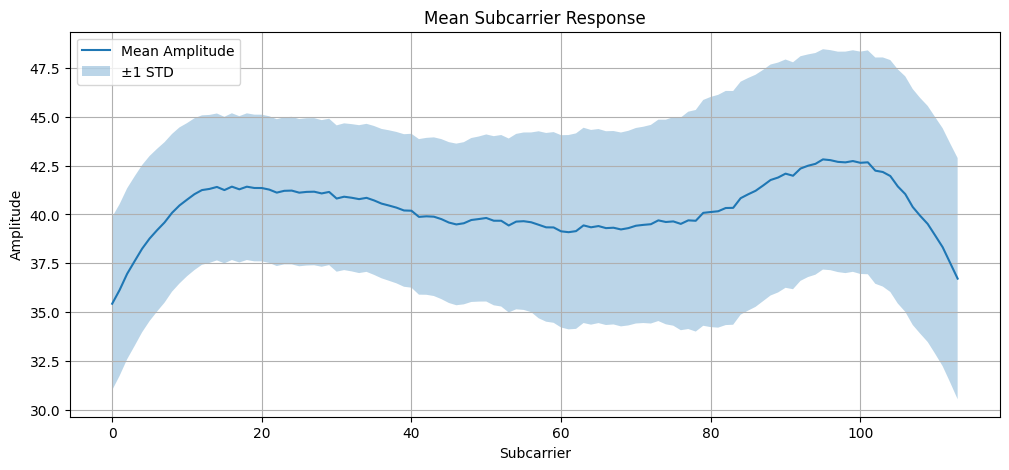


Antenna Correlation
Ant0-Ant1 : 0.0202
Ant0-Ant2 : 0.1837
Ant1-Ant2 : -0.1178

Deep Fade
Mean Position : 43.78872053872054
Std Position  : 48.28892394539411


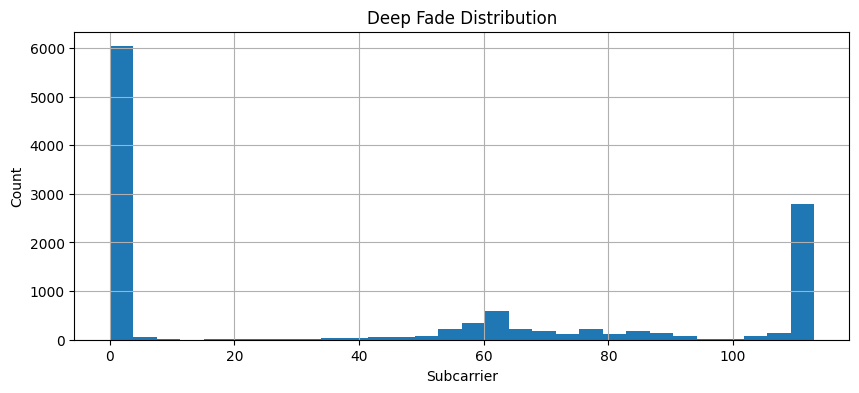


Delay Spread
Mean : nan
Std  : nan


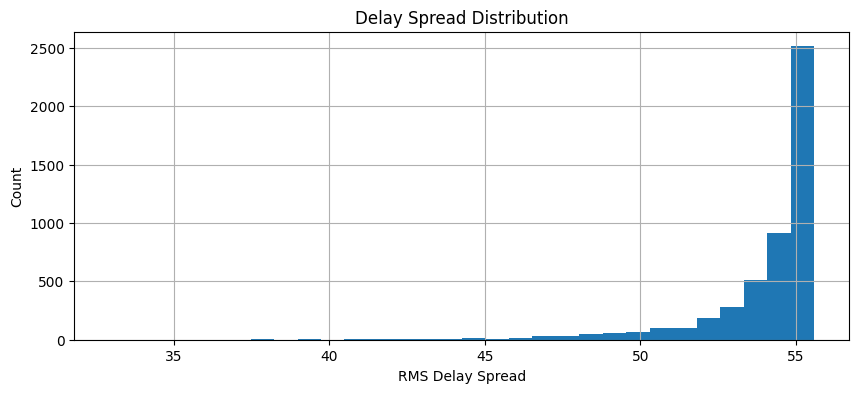

In [21]:
import os
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

# =====================================================
# 설정
# =====================================================

env_dirs = [
    "../E03",
]

target_actions = [
    "A01",
    "A12",
    "A08",
    "A27"
]

# =====================================================
# 데이터 로드
# =====================================================

all_amp = []
all_phase = []

for env in env_dirs:

    print(f"Loading {env}")

    for subject in os.listdir(env):

        subject_path = os.path.join(env, subject)

        if not os.path.isdir(subject_path):
            continue

        for action in target_actions:

            action_path = os.path.join(
                subject_path,
                action,
                "wifi-csi"
            )

            if not os.path.exists(action_path):
                continue

            files = sorted(
                f for f in os.listdir(action_path)
                if f.endswith(".mat")
            )

            for file in files:

                data = loadmat(
                    os.path.join(action_path, file)
                )

                amp = data["CSIamp"]
                phase = data["CSIphase"]

                amp[~np.isfinite(amp)] = np.nan
                phase[~np.isfinite(phase)] = np.nan

                all_amp.append(amp)
                all_phase.append(phase)

all_amp = np.stack(all_amp)
all_phase = np.stack(all_phase)

print()
print("Amplitude Shape :", all_amp.shape)
print("Phase Shape     :", all_phase.shape)

# =====================================================
# Feature 1
# Mean Subcarrier Response
# =====================================================

mean_amp = np.nanmean(
    all_amp,
    axis=(0,1,3)
)

# =====================================================
# Feature 2
# Std Subcarrier Response
# =====================================================

std_amp = np.nanstd(
    all_amp,
    axis=(0,1,3)
)

# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(12,5))

plt.plot(
    mean_amp,
    label="Mean Amplitude"
)

plt.fill_between(
    np.arange(114),
    mean_amp-std_amp,
    mean_amp+std_amp,
    alpha=0.3,
    label="±1 STD"
)

plt.xlabel("Subcarrier")
plt.ylabel("Amplitude")
plt.title("Mean Subcarrier Response")
plt.legend()
plt.grid()

plt.show()

# =====================================================
# Feature 3
# Antenna Correlation
# =====================================================

ant0 = all_amp[:,0,:,:].reshape(-1)
ant1 = all_amp[:,1,:,:].reshape(-1)
ant2 = all_amp[:,2,:,:].reshape(-1)

mask01 = np.isfinite(ant0) & np.isfinite(ant1)
mask02 = np.isfinite(ant0) & np.isfinite(ant2)
mask12 = np.isfinite(ant1) & np.isfinite(ant2)

corr01 = np.corrcoef(
    ant0[mask01],
    ant1[mask01]
)[0,1]

corr02 = np.corrcoef(
    ant0[mask02],
    ant2[mask02]
)[0,1]

corr12 = np.corrcoef(
    ant1[mask12],
    ant2[mask12]
)[0,1]

print()
print("===================================")
print("Antenna Correlation")
print("===================================")
print(f"Ant0-Ant1 : {corr01:.4f}")
print(f"Ant0-Ant2 : {corr02:.4f}")
print(f"Ant1-Ant2 : {corr12:.4f}")

# =====================================================
# Feature 4
# Deep Fade Distribution
# =====================================================

fade_positions = []

for i in range(all_amp.shape[0]):

    profile = np.nanmean(
        all_amp[i],
        axis=(0,2)
    )

    fade_positions.append(
        np.nanargmin(profile)
    )

fade_positions = np.array(
    fade_positions
)

print()
print("===================================")
print("Deep Fade")
print("===================================")
print("Mean Position :", fade_positions.mean())
print("Std Position  :", fade_positions.std())

plt.figure(figsize=(10,4))

plt.hist(
    fade_positions,
    bins=30
)

plt.xlabel("Subcarrier")
plt.ylabel("Count")
plt.title("Deep Fade Distribution")

plt.grid()

plt.show()

# =====================================================
# Feature 5
# Delay Spread Proxy
# =====================================================

sample_num = min(
    5000,
    all_amp.shape[0]
)

delay_spreads = []

for i in range(sample_num):

    amp = all_amp[i]
    phase = all_phase[i]

    csi = amp * np.exp(
        1j * phase
    )

    cir = np.fft.ifft(
        csi,
        axis=1
    )

    power = np.abs(cir)**2

    delay_axis = np.arange(
        power.shape[1]
    )

    power_mean = power.mean(
        axis=(0,2)
    )

    power_mean /= (
        power_mean.sum() + 1e-12
    )

    tau_mean = np.sum(
        delay_axis * power_mean
    )

    tau_rms = np.sqrt(
        np.sum(
            ((delay_axis-tau_mean)**2)
            * power_mean
        )
    )

    delay_spreads.append(
        tau_rms
    )

delay_spreads = np.array(
    delay_spreads
)

print()
print("===================================")
print("Delay Spread")
print("===================================")
print("Mean :", delay_spreads.mean())
print("Std  :", delay_spreads.std())

plt.figure(figsize=(10,4))

plt.hist(
    delay_spreads,
    bins=30
)

plt.xlabel("RMS Delay Spread")
plt.ylabel("Count")
plt.title("Delay Spread Distribution")

plt.grid()

plt.show()

In [22]:
import pandas as pd

df = pd.DataFrame({
    "subcarrier": np.arange(114),
    "mean_amp": mean_amp,
    "std_amp": std_amp
})

df.to_csv(
    "E03_stats.csv",
    index=False
)

In [23]:
import pandas as pd

print(pd.read_csv("E01_stats.csv").head())
print(pd.read_csv("E01_stats.csv").columns)

   subcarrier   mean_amp   std_amp
0           0  32.484295  5.667508
1           1  33.090097  5.544044
2           2  33.924009  5.428716
3           3  34.460190  5.346033
4           4  35.145203  5.254582
Index(['subcarrier', 'mean_amp', 'std_amp'], dtype='object')


In [24]:
import numpy as np

def compute_delay_spread(all_amp, all_phase, sample_num=3000):

    sample_num = min(sample_num, all_amp.shape[0])

    delay_spreads = []

    for i in range(sample_num):

        amp = all_amp[i]
        phase = all_phase[i]

        csi = amp * np.exp(1j * phase)

        # subcarrier 축
        cir = np.fft.ifft(csi, axis=1)

        power = np.abs(cir) ** 2

        power_mean = power.mean(axis=(0,2))

        power_mean /= (power_mean.sum() + 1e-12)

        delay_axis = np.arange(len(power_mean))

        tau_mean = np.sum(
            delay_axis * power_mean
        )

        tau_rms = np.sqrt(
            np.sum(
                ((delay_axis - tau_mean) ** 2)
                * power_mean
            )
        )

        delay_spreads.append(tau_rms)

    delay_spreads = np.array(delay_spreads)

    return (
        delay_spreads.mean(),
        delay_spreads.std(),
        delay_spreads
    )

In [25]:
def compute_antenna_corr(all_amp):

    ant0 = all_amp[:,0,:,:].reshape(-1)
    ant1 = all_amp[:,1,:,:].reshape(-1)
    ant2 = all_amp[:,2,:,:].reshape(-1)

    corr01 = np.corrcoef(
        ant0,
        ant1
    )[0,1]

    corr02 = np.corrcoef(
        ant0,
        ant2
    )[0,1]

    corr12 = np.corrcoef(
        ant1,
        ant2
    )[0,1]

    return corr01, corr02, corr12

In [26]:
def compute_phase_stats(all_phase):

    phase_mean = np.nanmean(all_phase)

    phase_std = np.nanstd(all_phase)

    return phase_mean, phase_std

In [ ]:
import pandas as pd

summary = pd.DataFrame({
    "env":[env_name],
    "delay_mean":[delay_mean],
    "delay_std":[delay_std],
    "corr01":[corr01],
    "corr02":[corr02],
    "corr12":[corr12],
    "phase_mean":[phase_mean],
    "phase_std":[phase_std]
})

summary.to_csv(
    f"{env_name}_summary.csv",
    index=False
)

In [35]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat

# =====================================================
# Load CSI
# =====================================================

def load_env_data(env_path, target_actions):

    all_amp = []
    all_phase = []

    print(f"Loading {env_path}")

    for subject in os.listdir(env_path):

        subject_path = os.path.join(
            env_path,
            subject
        )

        if not os.path.isdir(subject_path):
            continue

        for action in target_actions:

            action_path = os.path.join(
                subject_path,
                action,
                "wifi-csi"
            )

            if not os.path.exists(action_path):
                continue

            files = sorted(
                f for f in os.listdir(action_path)
                if f.endswith(".mat")
            )

            for file in files:

                data = loadmat(
                    os.path.join(
                        action_path,
                        file
                    )
                )

                amp = data["CSIamp"]
                phase = data["CSIphase"]

                amp[~np.isfinite(amp)] = np.nan
                phase[~np.isfinite(phase)] = np.nan

                all_amp.append(amp)
                all_phase.append(phase)

    all_amp = np.stack(all_amp)
    all_phase = np.stack(all_phase)

    print("AMP :", all_amp.shape)
    print("PHS :", all_phase.shape)

    return all_amp, all_phase

# =====================================================
# Statistics
# =====================================================

def compute_statistics(all_amp, all_phase):

    # -------------------------
    # Mean / Std Response
    # -------------------------

    mean_amp = np.nanmean(
        all_amp,
        axis=(0,1,3)
    )

    std_amp = np.nanstd(
        all_amp,
        axis=(0,1,3)
    )

    # -------------------------
    # Antenna Correlation
    # -------------------------

    ant0 = all_amp[:,0,:,:].reshape(-1)
    ant1 = all_amp[:,1,:,:].reshape(-1)
    ant2 = all_amp[:,2,:,:].reshape(-1)

    mask01 = np.isfinite(ant0) & np.isfinite(ant1)
    mask02 = np.isfinite(ant0) & np.isfinite(ant2)
    mask12 = np.isfinite(ant1) & np.isfinite(ant2)

    corr01 = np.corrcoef(
        ant0[mask01],
        ant1[mask01]
    )[0,1]

    corr02 = np.corrcoef(
        ant0[mask02],
        ant2[mask02]
    )[0,1]

    corr12 = np.corrcoef(
        ant1[mask12],
        ant2[mask12]
    )[0,1]

    # -------------------------
    # Deep Fade
    # -------------------------

    fade_positions = []

    for i in range(all_amp.shape[0]):

        profile = np.nanmean(
            all_amp[i],
            axis=(0,2)
        )

        fade_positions.append(
            np.nanargmin(profile)
        )

    fade_positions = np.array(
        fade_positions
    )

    fade_mean = fade_positions.mean()
    fade_std = fade_positions.std()

    # -------------------------
    # Delay Spread
    # -------------------------

    sample_num = min(
        3000,
        all_amp.shape[0]
    )

    delay_spreads = []

    for i in range(sample_num):

        amp = np.nan_to_num(
            all_amp[i],
            nan=0.0
        )

        phase = np.nan_to_num(
            all_phase[i],
            nan=0.0
        )

        csi = amp * np.exp(
            1j * phase
        )

        # (3,114,10)
        cir = np.fft.ifft(
            csi,
            axis=1
        )

        power = np.abs(cir)**2

        packet_delay = []

        for pkt in range(power.shape[2]):

            # 안테나 평균
            pdp = power[:,:,pkt].mean(axis=0)

            pdp = pdp / (
                pdp.sum() + 1e-12
            )

            tau = np.arange(
                len(pdp)
            )

            tau_mean = np.sum(
                tau * pdp
            )

            tau_rms = np.sqrt(
                np.sum(
                    ((tau - tau_mean)**2)
                    * pdp
                )
            )

            packet_delay.append(
                tau_rms
            )

        delay_spreads.append(
            np.mean(packet_delay)
        )

    delay_spreads = np.array(
        delay_spreads
    )

    return {
        "mean_amp": mean_amp,
        "std_amp": std_amp,
        "corr01": corr01,
        "corr02": corr02,
        "corr12": corr12,
        "fade_mean": fade_mean,
        "fade_std": fade_std,
        "delay_mean": delay_spreads.mean(),
        "delay_std": delay_spreads.std(),
        "delay_mean": float(delay_spreads.mean()),
        "delay_std": float(delay_spreads.std()),
        "delay_min": float(delay_spreads.min()),
        "delay_max": float(delay_spreads.max())
    }

# =====================================================
# Save
# =====================================================

def save_statistics(env_name, stats):

    # Subcarrier Profile

    pd.DataFrame({
        "subcarrier": np.arange(114),
        "mean_amp": stats["mean_amp"],
        "std_amp": stats["std_amp"]
    }).to_csv(
        f"{env_name}_profile.csv",
        index=False
    )

    # Summary

    pd.DataFrame({
        "env":[env_name],
        "corr01":[stats["corr01"]],
        "corr02":[stats["corr02"]],
        "corr12":[stats["corr12"]],
        "fade_mean":[stats["fade_mean"]],
        "fade_std":[stats["fade_std"]],
        "delay_mean":[stats["delay_mean"]],
        "delay_std":[stats["delay_std"]],
        "delay_min":[stats["delay_min"]],
        "delay_max":[stats["delay_max"]],
    }).to_csv(
        f"{env_name}_summary.csv",
        index=False
    )

    print(f"{env_name} saved")

In [36]:
target_actions = [
    "A01",
    "A12",
    "A08",
    "A27"
]

for env in [
    "../E01",
    "../E02",
    "../E03"
]:

    env_name = os.path.basename(env)

    amp, phase = load_env_data(
        env,
        target_actions
    )

    stats = compute_statistics(
        amp,
        phase
    )

    save_statistics(
        env_name,
        stats
    )

    print(stats)

Loading ../E01
AMP : (11880, 3, 114, 10)
PHS : (11880, 3, 114, 10)
E01 saved
{'mean_amp': array([32.48429503, 33.09009664, 33.9240087 , 34.46018989, 35.14520329,
       35.5962008 , 36.05629693, 36.37858902, 36.73959179, 37.05881086,
       37.21633167, 37.44478156, 37.60865849, 37.68153695, 37.82478589,
       37.81833307, 37.95070509, 37.85642261, 37.95825636, 37.94369781,
       38.0272157 , 38.00338956, 38.00056829, 38.07562005, 38.06361647,
       37.93965596, 37.97097793, 38.02168521, 38.13336528, 38.31253648,
       38.25870456, 38.45870068, 38.58296841, 38.63636331, 38.88129842,
       38.9513294 , 39.11276048, 39.26134604, 39.3946975 , 39.46863405,
       39.66414212, 39.58194393, 39.67583412, 39.79104706, 39.73281611,
       39.68649017, 39.60868973, 39.64221806, 39.73729921, 39.70183992,
       39.6437059 , 39.45854969, 39.40675549, 39.30274444, 39.42688516,
       39.40275138, 39.32834904, 39.02063773, 38.99935234, 38.96763122,
       38.84225384, 38.74989293, 38.74959846, 

In [37]:
import pandas as pd

print(pd.read_csv("E01_summary.csv"))
print(pd.read_csv("E02_summary.csv"))
print(pd.read_csv("E03_summary.csv"))

   env    corr01    corr02    corr12  fade_mean   fade_std  delay_mean  \
0  E01  0.307029  0.213276  0.056424  26.009428  39.405038   50.641487   

   delay_std  delay_min  delay_max  
0   4.158458  25.711211   55.66463  
   env    corr01    corr02    corr12  fade_mean   fade_std  delay_mean  \
0  E02  0.028462  0.089716  0.083426   38.82963  45.236376   51.785539   

   delay_std  delay_min  delay_max  
0   3.044488   33.78866  55.320693  
   env    corr01    corr02    corr12  fade_mean   fade_std  delay_mean  \
0  E03  0.020203  0.183693 -0.117832  43.788721  48.288924    52.30044   

   delay_std  delay_min  delay_max  
0   2.872832  32.877678  55.505263  
